In [31]:
#importing the libery
import pandas as pd
import sqlite3
from scipy.stats import chi2_contingency


In [32]:
# creating new data base for clean file
def convert_csv_into_db(customers, transactions, db_name):
    conn = sqlite3.connect(db_name)
    df1 = pd.read_csv(customers)
    df1.to_sql('customers_clean' , conn , if_exists = 'replace' , index=False )

    df2 = pd.read_csv(transactions)
    df2.to_sql('transactions_clean', conn , if_exists = 'replace' , index=False)
    #connections close
    conn.close()

In [33]:
open('customers_clean.csv','r').close()
open('transactions_clean.csv','r').close()

convert_csv_into_db('customers_clean.csv', 'transactions_clean.csv', 'ecommerce_clean.db')


In [34]:
conn = sqlite3.connect('ecommerce_clean.db')

table = pd.read_sql("SELECT name FROM sqlite_master WHERE type = 'table'", conn)
print(table)

                 name
0     customers_clean
1  transactions_clean


In [35]:
#checking if cancel/refund is caused by payment_method

In [36]:
query = """ SELECT payment_method, COUNT(*) as total_tx, SUM(CASE WHEN transaction_status IN('Cancelled','Refunded') THEN 
    1 ELSE 0 END) as bad_tx FROM transactions_clean GROUP BY payment_method"""

payment_summary = pd.read_sql(query,conn)

In [37]:
print(payment_summary)

  payment_method  total_tx  bad_tx
0  Bank Transfer      1654     219
1           Cash      1642     218
2    Credit Card      1670     213
3     Debit Card      1577     185
4       E-wallet      1656     202


In [39]:
payment_summary['bad_per'] = round(100 * payment_summary['bad_tx']/payment_summary['total_tx'],2)
payment_summary['good_tx'] = payment_summary['total_tx'] - payment_summary['bad_tx']
payment_summary['good_per'] = round(100 * payment_summary['good_tx']/payment_summary['total_tx'],2)


In [40]:
# Chi-square test: is the spread in cancel/refund rate across payment methods
# real, or could it just be random chance given our sample sizes?
contingency_table = payment_summary[['bad_tx', 'good_tx']].values
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print("p-value:", p_value)


p-value: 0.6209290938153031


In [41]:
#checking using discount_missing

In [42]:
query = """ SELECT discount_missing_flag, COUNT(*) as total_tx , SUM(CASE WHEN transaction_status IN('Cancelled','Refunded')
        THEN 1 ELSE 0 END) as bad_tx from transactions_clean GROUP BY discount_missing_flag"""

discount_summary = pd.read_sql(query,conn)
print(discount_summary)

   discount_missing_flag  total_tx  bad_tx
0                      0      7773     976
1                      1       426      61


In [43]:
discount_summary['good_tx'] = discount_summary['total_tx'] - discount_summary['bad_tx']
contingency_table = discount_summary[['bad_tx', 'good_tx']].values


In [44]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print("p-value:", p_value)



p-value: 0.3216622318758983


In [45]:
#checking using age
query = """ SELECT c.age_missing, COUNT(*) as total_tx , SUM(CASE WHEN t.transaction_status IN('Cancelled','Refunded')
        THEN 1 ELSE 0 END) AS bad_tx FROM customers_clean c JOIN transactions_clean t ON c.customer_id = t.customer_id  
        GROUP BY c.age_missing"""

age_summary = pd.read_sql(query,conn)
print(age_summary)

   age_missing  total_tx  bad_tx
0            0      7715     974
1            1       484      63


In [46]:
age_summary['good_tx'] = age_summary['total_tx'] - age_summary['bad_tx']
contingency_table = age_summary[['bad_tx', 'good_tx']].values
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print("p-value:", p_value)

p-value: 0.8563307906433942


In [47]:
#checking using state

In [48]:
query = """ SELECT c.state_missing, COUNT(*) as total_tx , SUM(CASE WHEN t.transaction_status IN('Cancelled','Refunded')
        THEN 1 ELSE 0 END) AS bad_tx FROM customers_clean c JOIN transactions_clean t ON c.customer_id = t.customer_id  
        GROUP BY c.state_missing"""

state_summary = pd.read_sql(query,conn)
print(state_summary)

   state_missing  total_tx  bad_tx
0              0      7752     971
1              1       447      66


In [49]:
state_summary['good_tx'] = state_summary['total_tx'] - state_summary['bad_tx']
contingency_table = state_summary[['bad_tx', 'good_tx']].values
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print("p-value:", p_value)

p-value: 0.1895811156547127


In [50]:
#checking useing subscribe

In [51]:
#finding value contained by subscribe
print(pd.read_sql("SELECT DISTINCT subscribe FROM customers_clean", conn))

  subscribe
0        No
1       Yes


In [52]:
query = """
SELECT c.subscribe,
       COUNT(*) AS total_tx,
       SUM(CASE WHEN t.transaction_status IN ('Cancelled','Refunded') THEN 1 ELSE 0 END) AS bad_tx
FROM customers_clean c
JOIN transactions_clean t ON c.customer_id = t.customer_id
GROUP BY c.subscribe
"""
subscribe_summary = pd.read_sql(query, conn)
print(subscribe_summary)

  subscribe  total_tx  bad_tx
0        No      2373     303
1       Yes      5826     734


In [53]:
subscribe_summary['good_tx'] = subscribe_summary['total_tx'] - subscribe_summary['bad_tx']
contingency_table = subscribe_summary[['bad_tx', 'good_tx']].values
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print("p-value:", p_value)

p-value: 0.8623953593095143


In [54]:
#checking trend of reveune vs time for timepass

In [55]:
print(pd.read_sql("PRAGMA table_info(transactions_clean)", conn))

    cid                   name     type  notnull dflt_value  pk
0     0         transaction_id     TEXT        0       None   0
1     1            customer_id     TEXT        0       None   0
2     2       transaction_date     TEXT        0       None   0
3     3             product_id     TEXT        0       None   0
4     4               quantity  INTEGER        0       None   0
5     5             unit_price  INTEGER        0       None   0
6     6         payment_method     TEXT        0       None   0
7     7       discount_applied     REAL        0       None   0
8     8     transaction_status     TEXT        0       None   0
9     9            review_text     TEXT        0       None   0
10   10  discount_missing_flag  INTEGER        0       None   0
11   11             has_review  INTEGER        0       None   0


In [56]:
query = """
SELECT strftime('%Y-%m', transaction_date) AS month,
       COUNT(*) AS tx_count,
       SUM(quantity * unit_price) AS gross_revenue,
       SUM(CASE WHEN transaction_status IN ('Cancelled','Refunded') THEN quantity * unit_price ELSE 0 END) AS lost_revenue
FROM transactions_clean
GROUP BY month
ORDER BY month
"""
monthly_summary = pd.read_sql(query, conn)
print(monthly_summary)

      month  tx_count  gross_revenue  lost_revenue
0   2023-10         3       22593000       3376000
1   2023-11         3       10941000             0
2   2023-12        14      182895000      20637000
3   2024-01         8       44462000      12200000
4   2024-02        18       93461000      20534000
5   2024-03        26      153740000      22170000
6   2024-04        30      152994000      21040000
7   2024-05        37      255478000      13654000
8   2024-06        44      267788000      35163000
9   2024-07        63      424822000      61109000
10  2024-08        58      482465000      59911000
11  2024-09       103      666442000      70651000
12  2024-10       789     5336335700     543060000
13  2024-11       792     5467376200     757464000
14  2024-12       819     5909102700     661602000
15  2025-01       896     5943368300     697808200
16  2025-02       824     5240896300     758818400
17  2025-03       808     5367624400     791211000
18  2025-04       196     12469

In [57]:
monthly_summary['lost_pct'] = round(100 * monthly_summary['lost_revenue'] / monthly_summary['gross_revenue'], 2)
print(monthly_summary)

      month  tx_count  gross_revenue  lost_revenue  lost_pct
0   2023-10         3       22593000       3376000     14.94
1   2023-11         3       10941000             0      0.00
2   2023-12        14      182895000      20637000     11.28
3   2024-01         8       44462000      12200000     27.44
4   2024-02        18       93461000      20534000     21.97
5   2024-03        26      153740000      22170000     14.42
6   2024-04        30      152994000      21040000     13.75
7   2024-05        37      255478000      13654000      5.34
8   2024-06        44      267788000      35163000     13.13
9   2024-07        63      424822000      61109000     14.38
10  2024-08        58      482465000      59911000     12.42
11  2024-09       103      666442000      70651000     10.60
12  2024-10       789     5336335700     543060000     10.18
13  2024-11       792     5467376200     757464000     13.85
14  2024-12       819     5909102700     661602000     11.20
15  2025-01       896   

In [58]:
# using state wise name if there any difference

In [59]:
query = """
SELECT c.state,
       COUNT(*) AS total_tx,
       SUM(CASE WHEN t.transaction_status IN ('Cancelled','Refunded') THEN 1 ELSE 0 END) AS bad_tx
FROM customers_clean c
JOIN transactions_clean t ON c.customer_id = t.customer_id
GROUP BY c.state
ORDER BY total_tx DESC
"""

In [60]:
state_by_value = pd.read_sql(query, conn)
state_by_value['bad_pct'] = round(100 * state_by_value['bad_tx'] / state_by_value['total_tx'], 2)
print(state_by_value.sort_values('bad_pct', ascending=False))

                        state  total_tx  bad_tx  bad_pct
33             Sulawesi Barat       134      24    17.91
25                DKI Jakarta       209      37    17.70
24           Kalimantan Utara       211      37    17.54
2                      Banten       304      48    15.79
20                    Lampung       217      34    15.67
16                       Aceh       237      37    15.61
32                      Jambi       148      23    15.54
3   Kepulauan Bangka Belitung       292      44    15.07
1              Kepulauan Riau       304      45    14.80
0                     Unknown       447      66    14.77
7                       Papua       272      38    13.97
12        Nusa Tenggara Barat       266      37    13.91
31         Kalimantan Selatan       157      21    13.38
21              DI Yogyakarta       217      29    13.36
27                 Jawa Barat       188      25    13.30
26                     Maluku       196      26    13.27
23          Kalimantan Tengah  

In [61]:
state_by_value['good_tx'] = state_by_value['total_tx'] - state_by_value['bad_tx']
contingency_table = state_by_value[['bad_tx', 'good_tx']].values
from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print("p-value:", p_value)

p-value: 0.008724729892562563


In [62]:
query = """
SELECT c.state,
       COUNT(*) AS total_tx,
       SUM(CASE WHEN t.transaction_status IN ('Cancelled','Refunded') THEN 1 ELSE 0 END) AS bad_tx
FROM customers_clean c
JOIN transactions_clean t ON c.customer_id = t.customer_id
WHERE c.state != 'Unknown'
GROUP BY c.state
ORDER BY total_tx DESC
"""
state_by_value_clean = pd.read_sql(query, conn)

In [63]:
state_by_value_clean['bad_pct'] = round(100 * state_by_value_clean['bad_tx'] / state_by_value_clean['total_tx'], 2)
print(state_by_value_clean.sort_values('bad_pct', ascending=False))

                        state  total_tx  bad_tx  bad_pct
32             Sulawesi Barat       134      24    17.91
24                DKI Jakarta       209      37    17.70
23           Kalimantan Utara       211      37    17.54
1                      Banten       304      48    15.79
19                    Lampung       217      34    15.67
15                       Aceh       237      37    15.61
31                      Jambi       148      23    15.54
2   Kepulauan Bangka Belitung       292      44    15.07
0              Kepulauan Riau       304      45    14.80
6                       Papua       272      38    13.97
11        Nusa Tenggara Barat       266      37    13.91
30         Kalimantan Selatan       157      21    13.38
20              DI Yogyakarta       217      29    13.36
26                 Jawa Barat       188      25    13.30
25                     Maluku       196      26    13.27
22          Kalimantan Tengah       213      28    13.15
3              Sumatera Utara  

In [64]:
state_by_value_clean['good_tx'] = state_by_value_clean['total_tx'] - state_by_value_clean['bad_tx']
contingency_table = state_by_value_clean[['bad_tx', 'good_tx']].values
from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print("p-value:", p_value)

p-value: 0.009084920046042453


In [65]:
# Now we are going to make charts

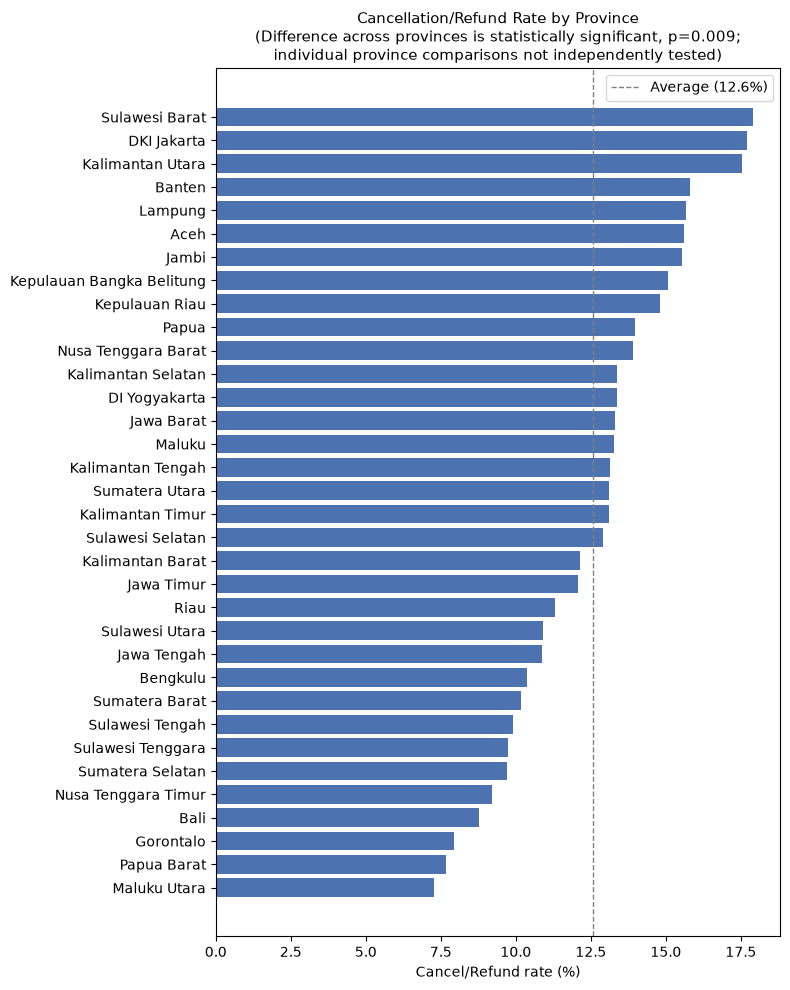

In [67]:
import matplotlib.pyplot as plt

df_sorted = state_by_value_clean.sort_values('bad_pct', ascending=True)
overall_avg = df_sorted['bad_pct'].mean()  # or use the true overall rate: 100*sum(bad_tx)/sum(total_tx)

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(df_sorted['state'], df_sorted['bad_pct'], color='#4C72B0')
ax.axvline(overall_avg, color='gray', linestyle='--', linewidth=1, label=f'Average ({overall_avg:.1f}%)')
ax.set_xlabel('Cancel/Refund rate (%)')
ax.set_title('Cancellation/Refund Rate by Province\n(Difference across provinces is statistically significant, p=0.009;\nindividual province comparisons not independently tested)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig('charts/04_state_cancel_rate.png')
plt.show()

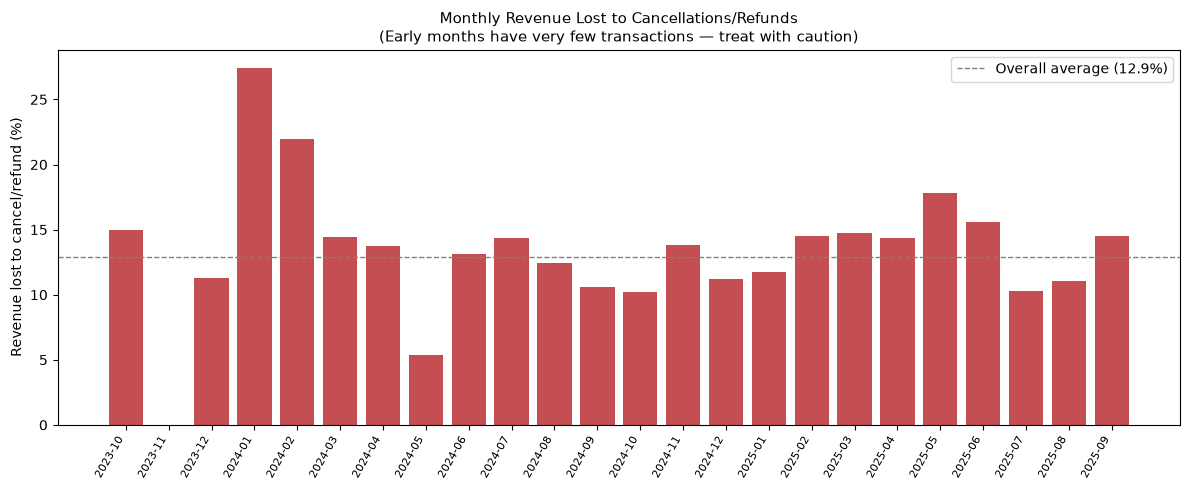

In [70]:
df_sorted = monthly_summary.sort_values('month', ascending=True)

# Weighted average (true overall rate), not a simple mean of 24 percentages 
# avoids letting tiny early months (3 transactions) count equally with 900-transaction months
overall_avg = 100 * df_sorted['lost_revenue'].sum() / df_sorted['gross_revenue'].sum()

fig, ax = plt.subplots(figsize=(12, 5))  # wide and short, suited to a time series with 24 x-axis labels
ax.bar(df_sorted['month'], df_sorted['lost_pct'], color='#C44E52')
ax.axhline(overall_avg, color='gray', linestyle='--', linewidth=1, label=f'Overall average ({overall_avg:.1f}%)')
ax.set_ylabel('Revenue lost to cancel/refund (%)')
ax.set_title('Monthly Revenue Lost to Cancellations/Refunds\n(Early months have very few transactions — treat with caution)', fontsize=11)
ax.legend()
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('charts/05_monthly_lost_revenue.png') 
plt.show()

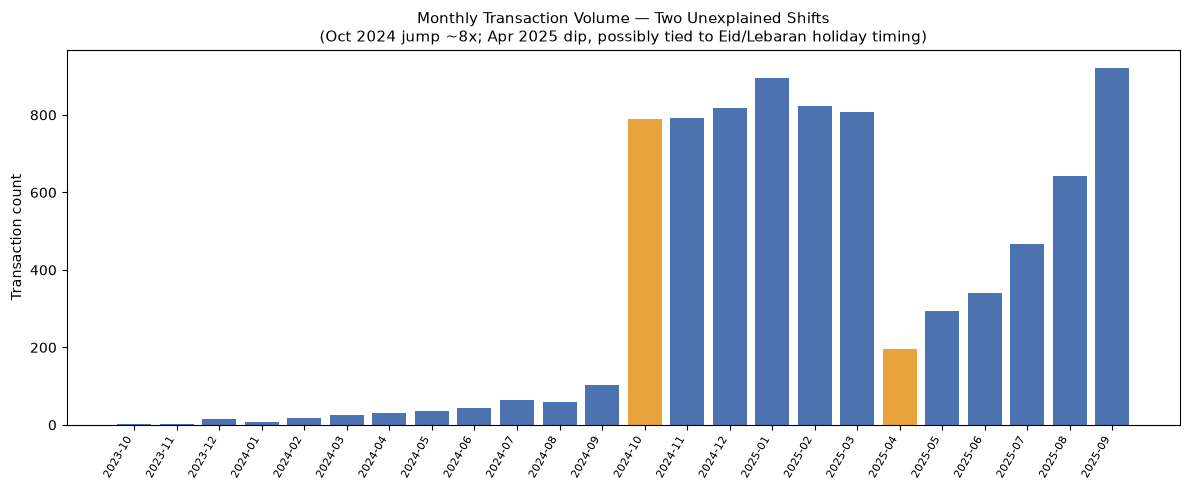

In [71]:
df_sorted = monthly_summary.sort_values('month', ascending=True)

# Color the two anomaly months differently so they stand out immediately,
# rather than making the reader scan all 24 bars to spot them
colors = ['#E8A33D' if m in ['2024-10', '2025-04'] else '#4C72B0' for m in df_sorted['month']]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_sorted['month'], df_sorted['tx_count'], color=colors)
ax.set_ylabel('Transaction count')
ax.set_title('Monthly Transaction Volume — Two Unexplained Shifts\n(Oct 2024 jump ~8x; Apr 2025 dip, possibly tied to Eid/Lebaran holiday timing)', fontsize=11)
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('charts/06_monthly_volume.png')
plt.show()

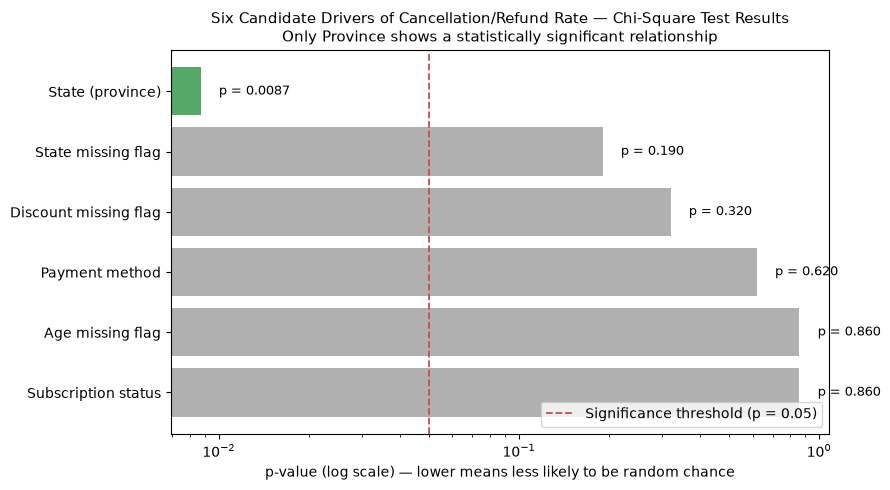

In [72]:
tests = [
    ("State (province)", 0.0087, True),
    ("State missing flag", 0.19, False),
    ("Discount missing flag", 0.32, False),
    ("Payment method", 0.62, False),
    ("Age missing flag", 0.86, False),
    ("Subscription status", 0.86, False),
]

labels = [t[0] for t in tests]
pvalues = [t[1] for t in tests]
significant = [t[2] for t in tests]
colors = ['#55A868' if sig else '#B0B0B0' for sig in significant]  # green = significant, gray = not

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels, pvalues, color=colors)
ax.axvline(0.05, color='#C44E52', linestyle='--', linewidth=1.3, label='Significance threshold (p = 0.05)')
ax.set_xscale('log')  # p-values span 0.0087 to 0.86 -- log scale keeps small values readable
ax.set_xlabel('p-value (log scale) — lower means less likely to be random chance')
ax.set_title('Six Candidate Drivers of Cancellation/Refund Rate — Chi-Square Test Results\nOnly Province shows a statistically significant relationship', fontsize=11)
ax.invert_yaxis()  # most significant test at top

# annotate each bar with its exact p-value
for bar, p in zip(bars, pvalues):
    ax.text(bar.get_width()*1.15, bar.get_y() + bar.get_height()/2,
             f"p = {p:.3f}" if p >= 0.01 else f"p = {p:.4f}",
             va='center', fontsize=9)

ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('charts/07_significance_summary.png', dpi=110)
plt.show()